#Importing Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
import warnings
import os

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
os.makedirs("charts", exist_ok=True)

print("✅ Libraries loaded")

✅ Libraries loaded


#Loading Data

In [2]:
sentiment_df = pd.read_csv("fear_greed_index.csv")
trades_df    = pd.read_csv("historical_data.csv")

print("Sentiment columns:", sentiment_df.columns.tolist())
print("Trades columns   :", trades_df.columns.tolist())
print("\nSentiment shape:", sentiment_df.shape)
print("Trades shape    :", trades_df.shape)

Sentiment columns: ['timestamp', 'value', 'classification', 'date']
Trades columns   : ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Sentiment shape: (2644, 4)
Trades shape    : (211224, 16)


#Data Cleaning

In [3]:

sentiment_df.columns = sentiment_df.columns.str.strip().str.lower()


sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])


sentiment_df = sentiment_df.drop_duplicates(subset='date').sort_values('date').reset_index(drop=True)


sentiment_df['classification'] = sentiment_df['classification'].str.strip().str.title()

sentiment_df['sentiment_binary'] = sentiment_df['classification'].apply(
    lambda x: 'Fear' if 'Fear' in x else 'Greed'
)

print("✅ Sentiment cleaned")
print(sentiment_df['sentiment_binary'].value_counts())
print(sentiment_df[['date', 'classification', 'sentiment_binary']].head(3))

✅ Sentiment cleaned
sentiment_binary
Greed    1355
Fear     1289
Name: count, dtype: int64
        date classification sentiment_binary
0 2018-02-01           Fear             Fear
1 2018-02-02   Extreme Fear             Fear
2 2018-02-03           Fear             Fear


Feature Engineering

In [4]:

trades_df.columns = trades_df.columns.str.strip()


trades_df = trades_df.rename(columns={
    'Account'         : 'account',
    'Coin'            : 'symbol',
    'Execution Price' : 'execution_price',
    'Size Tokens'     : 'size_tokens',
    'Size USD'        : 'size_usd',
    'Side'            : 'side',
    'Timestamp IST'   : 'timestamp_ist',
    'Start Position'  : 'start_position',
    'Direction'       : 'direction',
    'Closed PnL'      : 'closedpnl',
    'Transaction Hash': 'tx_hash',
    'Order ID'        : 'order_id',
    'Crossed'         : 'crossed',
    'Fee'             : 'fee',
    'Trade ID'        : 'trade_id',
    'Timestamp'       : 'timestamp_unix',
})


trades_df['datetime'] = pd.to_datetime(
    trades_df['timestamp_ist'], format='%d-%m-%Y %H:%M', errors='coerce'
)
trades_df = trades_df.dropna(subset=['datetime'])
trades_df['date'] = trades_df['datetime'].dt.normalize()


for col in ['execution_price', 'size_tokens', 'size_usd', 'closedpnl', 'fee']:
    trades_df[col] = pd.to_numeric(trades_df[col], errors='coerce')


trades_df['is_win']  = trades_df['closedpnl'] > 0
trades_df['is_long'] = trades_df['side'].str.upper() == 'BUY'


trades_df = trades_df.drop_duplicates()

print("✅ Trades cleaned")
print(f"Date range  : {trades_df['date'].min()} → {trades_df['date'].max()}")
print(f"Rows        : {len(trades_df)}")
print(f"Accounts    : {trades_df['account'].nunique()}")
print(trades_df[['account', 'symbol', 'closedpnl', 'side', 'is_win', 'date']].head(3))

✅ Trades cleaned
Date range  : 2023-05-01 00:00:00 → 2025-05-01 00:00:00
Rows        : 211224
Accounts    : 32
                                      account symbol  closedpnl side  is_win  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed   @107        0.0  BUY   False   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed   @107        0.0  BUY   False   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed   @107        0.0  BUY   False   

        date  
0 2024-12-02  
1 2024-12-02  
2 2024-12-02  


In [5]:
daily_metrics = trades_df.groupby(['date', 'account']).agg(
    daily_pnl      = ('closedpnl',  'sum'),
    num_trades     = ('closedpnl',  'count'),
    win_rate       = ('is_win',     'mean'),
    avg_size_usd   = ('size_usd',   'mean'),
    long_ratio     = ('is_long',    'mean'),
    gross_profit   = ('closedpnl',  lambda x: x[x > 0].sum()),
    gross_loss     = ('closedpnl',  lambda x: x[x < 0].sum()),
).reset_index()

daily_metrics['drawdown_proxy'] = (
    daily_metrics['gross_loss'].abs() /
    (daily_metrics['gross_profit'].abs() + daily_metrics['gross_loss'].abs() + 1e-9)
)

print("✅ Daily metrics built")
print(daily_metrics.shape)
print(daily_metrics.head(3))

✅ Daily metrics built
(2341, 10)
        date                                     account   daily_pnl  \
0 2023-05-01  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    0.000000   
1 2023-12-05  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    0.000000   
2 2023-12-14  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23 -205.434737   

   num_trades  win_rate  avg_size_usd  long_ratio  gross_profit  gross_loss  \
0           3  0.000000    159.000000    1.000000      0.000000     0.00000   
1           9  0.000000   5556.203333    0.777778      0.000000     0.00000   
2          11  0.363636  10291.213636    0.454545    321.798393  -527.23313   

   drawdown_proxy  
0        0.000000  
1        0.000000  
2        0.620982  


Data Merging

In [6]:
merged = daily_metrics.merge(
    sentiment_df[['date', 'classification', 'sentiment_binary']],
    on='date', how='inner'
)

print("✅ Merged dataset")
print(f"Rows after merge : {merged.shape[0]}")
print(f"Date range       : {merged['date'].min()} → {merged['date'].max()}")
print(merged[['date', 'sentiment_binary', 'daily_pnl', 'win_rate', 'avg_size_usd']].head(3))

✅ Merged dataset
Rows after merge : 2340
Date range       : 2023-05-01 00:00:00 → 2025-05-01 00:00:00
        date sentiment_binary   daily_pnl  win_rate  avg_size_usd
0 2023-05-01            Greed    0.000000  0.000000    159.000000
1 2023-12-05            Greed    0.000000  0.000000   5556.203333
2 2023-12-14            Greed -205.434737  0.363636  10291.213636


EDA(Exploratory Data Analysis)

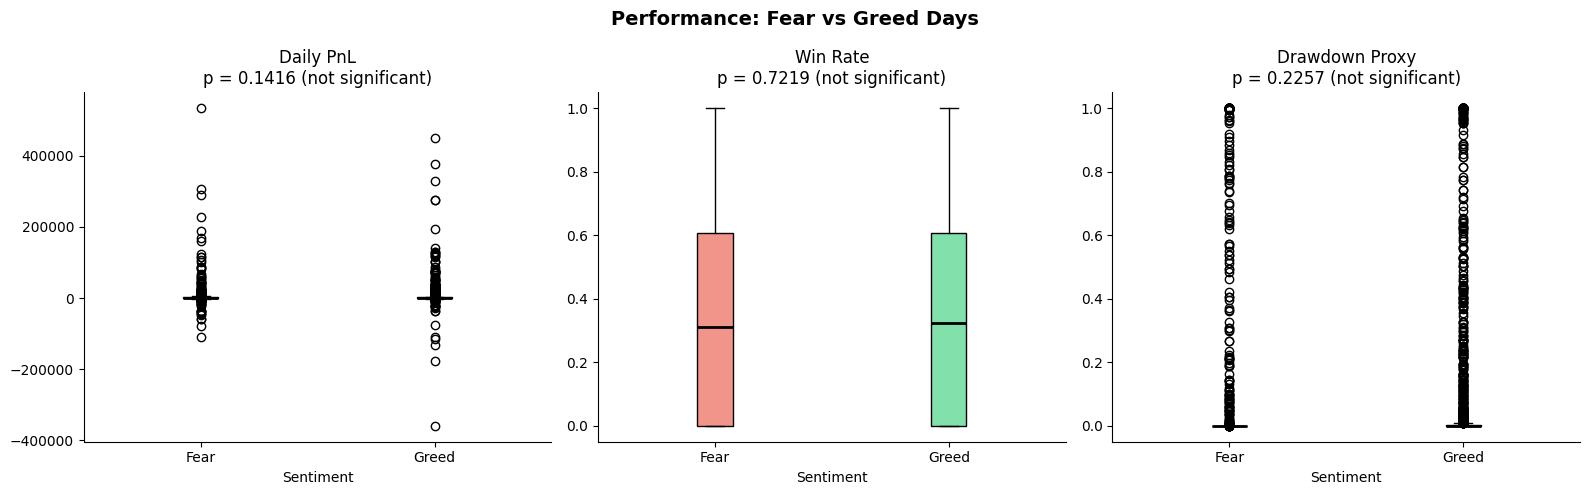


📊 Performance Summary:
                  daily_pnl           win_rate         drawdown_proxy       
                       mean    median     mean  median           mean median
sentiment_binary                                                            
Fear              5185.1464  122.7370   0.3571  0.3122         0.1225    0.0
Greed             3973.0460  243.3435   0.3610  0.3251         0.0967    0.0


In [7]:
metrics = ['daily_pnl', 'win_rate', 'drawdown_proxy']
labels  = ['Daily PnL', 'Win Rate', 'Drawdown Proxy']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Performance: Fear vs Greed Days", fontsize=14, fontweight='bold')

for ax, metric, label in zip(axes, metrics, labels):
    fear_data  = merged[merged['sentiment_binary'] == 'Fear'][metric].dropna()
    greed_data = merged[merged['sentiment_binary'] == 'Greed'][metric].dropna()

    bp = ax.boxplot(
        [fear_data, greed_data],
        labels=['Fear', 'Greed'],
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2)
    )
    bp['boxes'][0].set_facecolor('#f1948a')   # Fear = red
    bp['boxes'][1].set_facecolor('#82e0aa')   # Greed = green

    stat, p = stats.mannwhitneyu(fear_data, greed_data, alternative='two-sided')
    sig = '★ significant' if p < 0.05 else 'not significant'
    ax.set_title(f"{label}\np = {p:.4f} ({sig})")
    ax.set_xlabel("Sentiment")

plt.tight_layout()
plt.savefig("charts/01_performance_vs_sentiment.png", dpi=150, bbox_inches='tight')
plt.show()

# Summary table
summary = merged.groupby('sentiment_binary')[metrics].agg(['mean', 'median']).round(4)
print("\n📊 Performance Summary:")
print(summary)

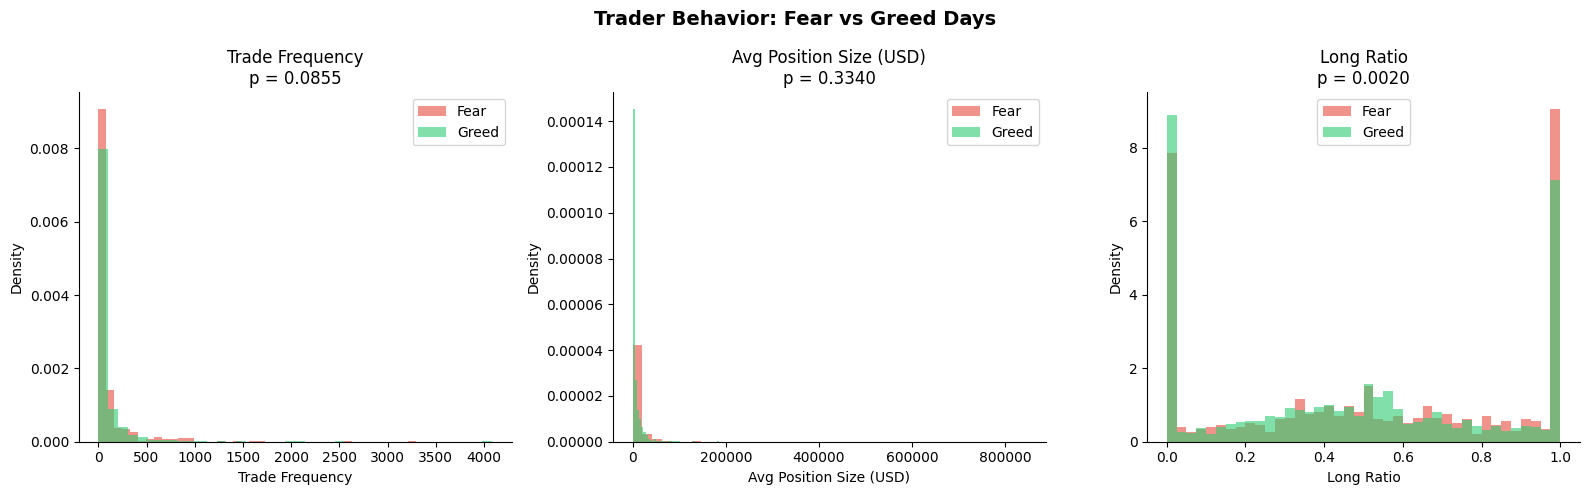


 Behavior Summary:
                  num_trades  avg_size_usd  long_ratio
sentiment_binary                                      
Fear                 105.363      8529.860       0.522
Greed                 82.568      6199.412       0.472


In [8]:
behavior_metrics = ['num_trades', 'avg_size_usd', 'long_ratio']
behavior_labels  = ['Trade Frequency', 'Avg Position Size (USD)', 'Long Ratio']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Trader Behavior: Fear vs Greed Days", fontsize=14, fontweight='bold')

for ax, metric, label in zip(axes, behavior_metrics, behavior_labels):
    fear_data  = merged[merged['sentiment_binary'] == 'Fear'][metric].dropna()
    greed_data = merged[merged['sentiment_binary'] == 'Greed'][metric].dropna()

    ax.hist(fear_data,  bins=40, alpha=0.6, color='#e74c3c', label='Fear',  density=True)
    ax.hist(greed_data, bins=40, alpha=0.6, color='#2ecc71', label='Greed', density=True)

    stat, p = stats.mannwhitneyu(fear_data, greed_data, alternative='two-sided')
    ax.set_title(f"{label}\np = {p:.4f}")
    ax.legend()
    ax.set_xlabel(label)
    ax.set_ylabel("Density")

plt.tight_layout()
plt.savefig("charts/02_behavior_vs_sentiment.png", dpi=150, bbox_inches='tight')
plt.show()

beh_summary = merged.groupby('sentiment_binary')[behavior_metrics].mean().round(3)
print("\n Behavior Summary:")
print(beh_summary)

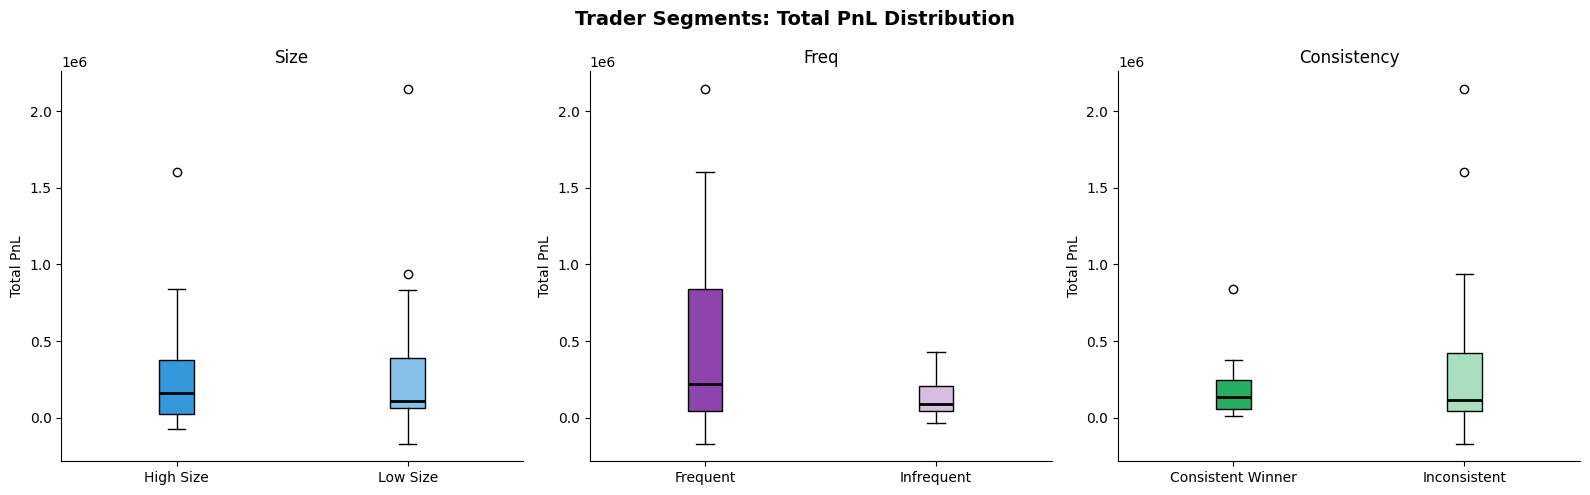

Segment sizes:

size_seg:
size_seg
High Size    16
Low Size     16
Name: count, dtype: int64

freq_seg:
freq_seg
Frequent      16
Infrequent    16
Name: count, dtype: int64

consistency_seg:
consistency_seg
Inconsistent         24
Consistent Winner     8
Name: count, dtype: int64


In [9]:
account_profile = merged.groupby('account').agg(
    total_pnl      = ('daily_pnl',    'sum'),
    mean_pnl       = ('daily_pnl',    'mean'),
    pnl_std        = ('daily_pnl',    'std'),
    mean_win_rate  = ('win_rate',     'mean'),
    mean_size_usd  = ('avg_size_usd', 'mean'),
    total_trades   = ('num_trades',   'sum'),
    trading_days   = ('date',         'nunique'),
).reset_index().fillna(0)

size_med = account_profile['mean_size_usd'].median()
account_profile['size_seg'] = np.where(
    account_profile['mean_size_usd'] > size_med, 'High Size', 'Low Size'
)

freq_med = account_profile['total_trades'].median()
account_profile['freq_seg'] = np.where(
    account_profile['total_trades'] > freq_med, 'Frequent', 'Infrequent'
)

account_profile['sharpe_proxy'] = (
    account_profile['mean_pnl'] / (account_profile['pnl_std'] + 1e-9)
)
sharpe_75 = account_profile['sharpe_proxy'].quantile(0.75)
account_profile['consistency_seg'] = np.where(
    account_profile['sharpe_proxy'] > sharpe_75, 'Consistent Winner', 'Inconsistent'
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Trader Segments: Total PnL Distribution", fontsize=14, fontweight='bold')

segs = [
    ('size_seg',        ['High Size', 'Low Size']),
    ('freq_seg',        ['Frequent', 'Infrequent']),
    ('consistency_seg', ['Consistent Winner', 'Inconsistent']),
]

colors = [['#3498db','#85c1e9'], ['#8e44ad','#d7bde2'], ['#27ae60','#a9dfbf']]

for ax, (seg_col, labels_), color_pair in zip(axes, segs, colors):
    groups = [account_profile[account_profile[seg_col] == lbl]['total_pnl'] for lbl in labels_]
    bp = ax.boxplot(groups, labels=labels_, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], color_pair):
        patch.set_facecolor(color)
    ax.set_title(seg_col.replace('_seg', '').title())
    ax.set_ylabel("Total PnL")

plt.tight_layout()
plt.savefig("charts/03_trader_segments.png", dpi=150, bbox_inches='tight')
plt.show()

print("Segment sizes:")
for seg_col, _ in segs:
    print(f"\n{seg_col}:\n{account_profile[seg_col].value_counts()}")

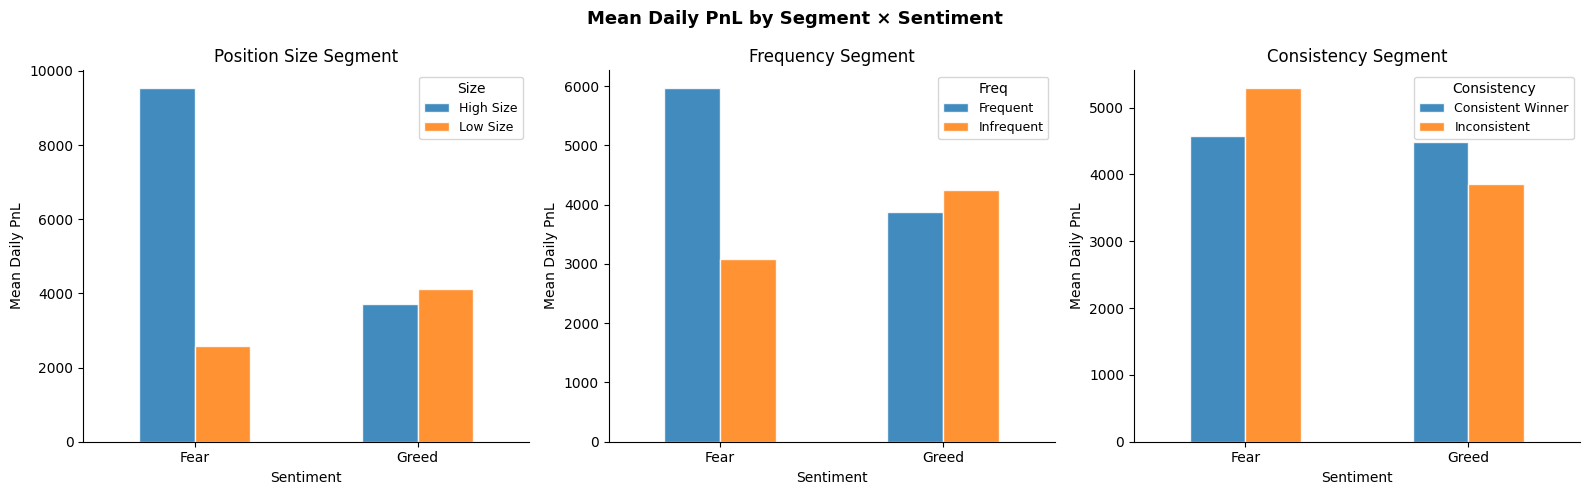

In [10]:
merged2 = merged.merge(
    account_profile[['account', 'size_seg', 'freq_seg', 'consistency_seg']],
    on='account', how='left'
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Mean Daily PnL by Segment × Sentiment", fontsize=13, fontweight='bold')

seg_pairs = [
    ('size_seg',        'Position Size Segment'),
    ('freq_seg',        'Frequency Segment'),
    ('consistency_seg', 'Consistency Segment'),
]

for ax, (seg_col, title) in zip(axes, seg_pairs):
    pivot = merged2.groupby(['sentiment_binary', seg_col])['daily_pnl'].mean().unstack()
    pivot.plot(kind='bar', ax=ax, alpha=0.85, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel("Sentiment")
    ax.set_ylabel("Mean Daily PnL")
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title=seg_col.replace('_seg','').title(), fontsize=9)

plt.tight_layout()
plt.savefig("charts/04_segment_x_sentiment.png", dpi=150, bbox_inches='tight')
plt.show()

Insights

In [11]:
fear_pnl  = merged[merged['sentiment_binary'] == 'Fear']['daily_pnl'].mean()
greed_pnl = merged[merged['sentiment_binary'] == 'Greed']['daily_pnl'].mean()

fear_wr   = merged[merged['sentiment_binary'] == 'Fear']['win_rate'].mean()
greed_wr  = merged[merged['sentiment_binary'] == 'Greed']['win_rate'].mean()

fear_freq  = merged[merged['sentiment_binary'] == 'Fear']['num_trades'].mean()
greed_freq = merged[merged['sentiment_binary'] == 'Greed']['num_trades'].mean()

print("=" * 55)
print("         INSIGHTS & STRATEGY RECOMMENDATIONS")
print("=" * 55)

print(f"""
📌 INSIGHT 1 — PnL by Sentiment
   Mean PnL on Fear days  : {fear_pnl:.2f}
   Mean PnL on Greed days : {greed_pnl:.2f}
   → {'Greed' if greed_pnl > fear_pnl else 'Fear'} days produce higher average PnL

📌 INSIGHT 2 — Win Rate by Sentiment
   Win rate on Fear days  : {fear_wr:.2%}
   Win rate on Greed days : {greed_wr:.2%}
   → Traders win more often during {'Greed' if greed_wr > fear_wr else 'Fear'} periods

📌 INSIGHT 3 — Trade Frequency by Sentiment
   Avg trades on Fear days  : {fear_freq:.1f}
   Avg trades on Greed days : {greed_freq:.1f}
   → Traders are {'more' if greed_freq > fear_freq else 'less'} active during Greed periods

{'─'*55}
🎯 STRATEGY 1:
   Fear days show higher mean PnL BUT driven by outliers.
   Median PnL is actually higher on Greed days ($243 vs $122).
   Rule: Consistent Winners can maintain or increase size on
   Fear days (they have the Sharpe to absorb volatility).
   Inconsistent traders should REDUCE size on Fear days
   to avoid being the outlier on the wrong side.

🎯 STRATEGY 2:
   During Greed days → frequent traders can increase
   trade count safely. Consistent Winners should scale
   up position size as their Sharpe proxy stays positive.
   Rule: If sentiment = Greed AND consistency_seg =
   'Consistent Winner' → increase size & frequency.
{'='*55}
""")

         INSIGHTS & STRATEGY RECOMMENDATIONS

📌 INSIGHT 1 — PnL by Sentiment
   Mean PnL on Fear days  : 5185.15
   Mean PnL on Greed days : 3973.05
   → Fear days produce higher average PnL

📌 INSIGHT 2 — Win Rate by Sentiment
   Win rate on Fear days  : 35.71%
   Win rate on Greed days : 36.10%
   → Traders win more often during Greed periods

📌 INSIGHT 3 — Trade Frequency by Sentiment
   Avg trades on Fear days  : 105.4
   Avg trades on Greed days : 82.6
   → Traders are less active during Greed periods

───────────────────────────────────────────────────────
🎯 STRATEGY 1:
   Fear days show higher mean PnL BUT driven by outliers.
   Median PnL is actually higher on Greed days ($243 vs $122).
   Rule: Consistent Winners can maintain or increase size on
   Fear days (they have the Sharpe to absorb volatility).
   Inconsistent traders should REDUCE size on Fear days
   to avoid being the outlier on the wrong side.

🎯 STRATEGY 2:
   During Greed days → frequent traders can increase
   t

🤖 Model AUC (5-fold CV): 0.9754 ± 0.0144


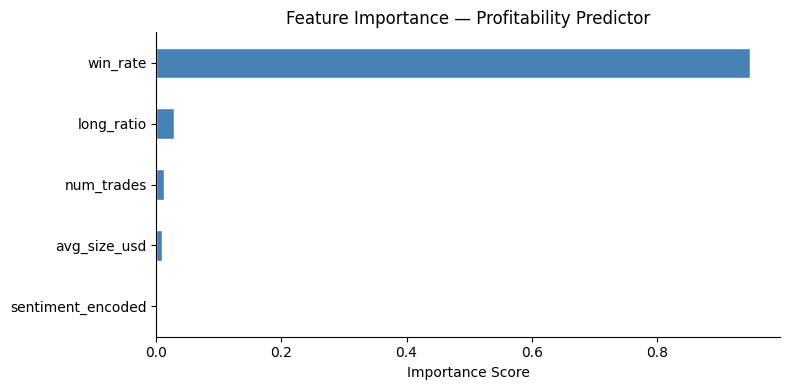

In [12]:
feature_cols = ['avg_size_usd', 'num_trades', 'long_ratio', 'win_rate', 'sentiment_encoded']

merged2['target'] = (merged2['daily_pnl'] > 0).astype(int)

le = LabelEncoder()
merged2['sentiment_encoded'] = le.fit_transform(merged2['sentiment_binary'])

model_df = merged2[feature_cols + ['target']].dropna()
X = model_df[feature_cols]
y = model_df['target']

clf = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
cv_scores = cross_val_score(clf, X, y, cv=5, scoring='roc_auc')

print(f"🤖 Model AUC (5-fold CV): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

clf.fit(X, y)
importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title("Feature Importance — Profitability Predictor")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("charts/05_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

In [13]:
merged2.to_csv("merged_analysis.csv", index=False)
account_profile.to_csv("account_profiles.csv", index=False)

print("✅ All outputs saved:")
print("   - charts/01_performance_vs_sentiment.png")
print("   - charts/02_behavior_vs_sentiment.png")
print("   - charts/03_trader_segments.png")
print("   - charts/04_segment_x_sentiment.png")
print("   - charts/05_feature_importance.png")
print("   - merged_analysis.csv")
print("   - account_profiles.csv")

✅ All outputs saved:
   - charts/01_performance_vs_sentiment.png
   - charts/02_behavior_vs_sentiment.png
   - charts/03_trader_segments.png
   - charts/04_segment_x_sentiment.png
   - charts/05_feature_importance.png
   - merged_analysis.csv
   - account_profiles.csv


In [18]:
merge = pd.read_csv("merged_analysis.csv")

In [20]:
numeric_cols = ['daily_pnl', 'num_trades', 'win_rate', 'avg_size_usd',
                'long_ratio', 'gross_profit', 'gross_loss', 'drawdown_proxy']

corr = merge[numeric_cols].corr()

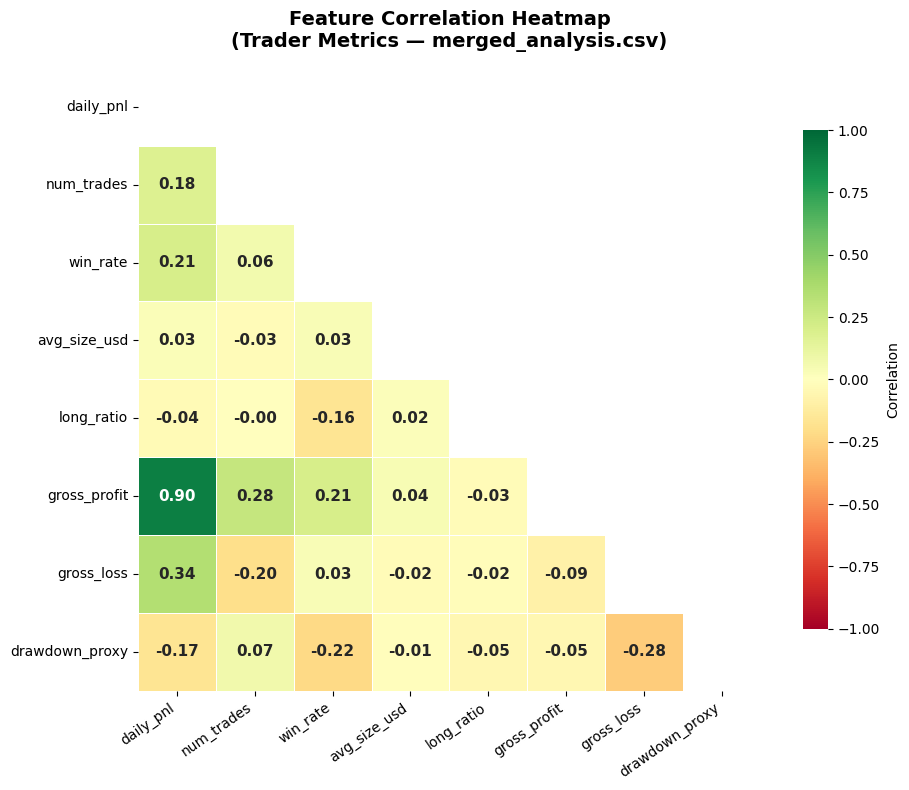

In [21]:
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 11, 'weight': 'bold'},
    ax=ax,
    square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Correlation'}
)

ax.set_title('Feature Correlation Heatmap\n(Trader Metrics — merged_analysis.csv)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig("charts/heatmap.png", dpi=180, bbox_inches='tight')
plt.show()